****Load and Prepare the Dataset****

In [2]:
#importing required liabraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import webbrowser
import os
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4
from reportlab.lib.units import inch
from IPython.display import display, HTML
from datetime import datetime

In [3]:
# Load dataset 
df = pd.read_csv("WebTraffic 1.csv", sep=';')

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

df.head()

,date,page,source,visits,unique_visitors,bounce_rate
0,2025-10-13,Home,Direct,180,150,0.42
1,2025-10-13,Home,Search,220,200,0.35
2,2025-10-13,Home,Social,90,80,0.48
3,2025-10-13,Home,Referral,60,55,0.40
4,2025-10-13,Courses,Direct,95,82,0.38


In [4]:
#group trends by day
trend = df.groupby(df['date'].dt.date)['visits'].sum().reset_index()
trend.head(10).style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', 'black'), ('color', 'white'), ('font-weight', 'bold')]}
]).highlight_max(color='green', subset=['visits'])


,date,visits
0,2025-10-13,1010
1,2025-10-14,1035
2,2025-10-15,1019
3,2025-10-16,1085
4,2025-10-17,1152
5,2025-10-18,1111
6,2025-10-19,1062


*Traffic Distribution by Source*

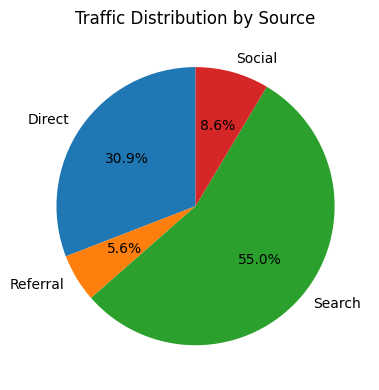

In [5]:
# Create source summary
source_visits = df.groupby('source')['visits'].sum().reset_index()
plt.figure(figsize=(4,4))
plt.pie(
    source_visits['visits'], 
    labels=source_visits['source'], 
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Traffic Distribution by Source")
plt.tight_layout()
plt.savefig("source_pie_chart.png")
plt.show()

*Total Visits by Page*

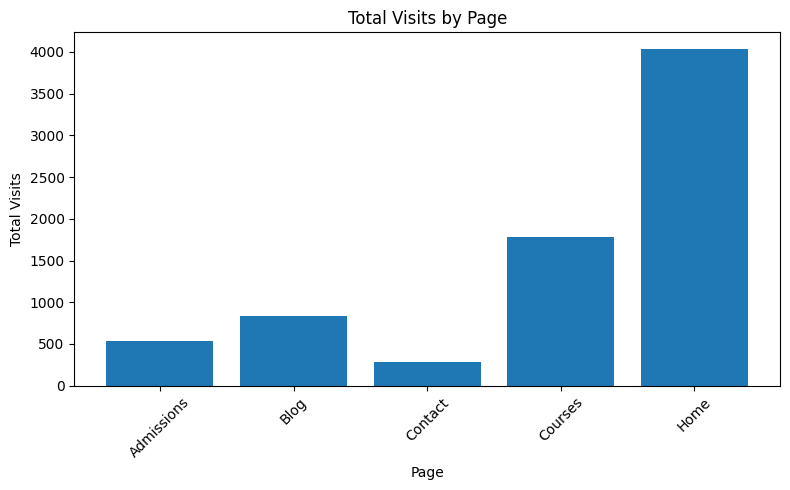

In [6]:
page_visits = df.groupby('page')['visits'].sum().reset_index()
plt.figure(figsize=(8,5))
plt.bar(page_visits['page'], page_visits['visits'])
plt.title("Total Visits by Page")
plt.xlabel("Page")
plt.ylabel("Total Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("page_bar_chart.png")
plt.show()

*Interactive Web Traffic Trend*

In [7]:
fig = px.line(trend, x='date', y='visits',
              title="Interactive Web Traffic Trend")
fig.write_html("interactive_chart.html")
plt.savefig("interactive_chart.png")
fig.show()

<Figure size 640x480 with 0 Axes>

*correlation*

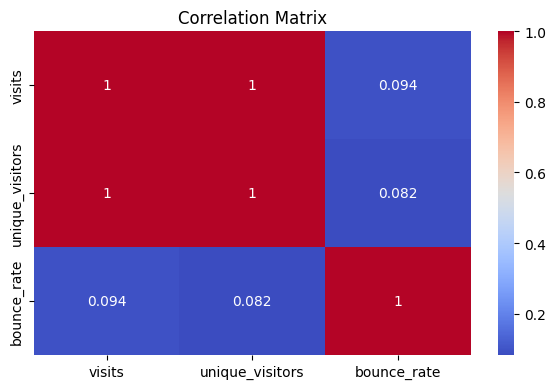

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['visits','unique_visitors','bounce_rate']].corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation.png")
plt.show()

*insights*

In [9]:
from IPython.display import HTML, display

# column date to  datetime
trend['date'] = pd.to_datetime(trend['date'])

# Calculations
total_visits = int(trend['visits'].sum())
avg_visits = float(trend['visits'].mean())

max_visits = int(trend['visits'].max())
min_visits = int(trend['visits'].min())

peak_day = trend.loc[trend['visits'].idxmax(), 'date']
lowest_day = trend.loc[trend['visits'].idxmin(), 'date']

# Professional KPI Cards UI
html_ui = f"""
<div style="display: flex; gap: 20px; font-family: sans-serif; margin: 20px 0;">

    <div style="flex: 1; padding: 15px; background: black; color: white; border-radius: 8px; text-align: center;">
        <small style="text-transform: uppercase; opacity: 0.8;">Total Visits</small>
        <h2 style="margin: 5px 0;">{total_visits:,}</h2>
    </div>

    <div style="flex: 1; padding: 15px; background: #f4f4f4; border: 2px solid black; border-radius: 8px; text-align: center;">
        <small style="text-transform: uppercase; color: #666;">Peak Traffic</small>
        <h2 style="margin: 5px 0; color: #27ae60;">{max_visits:,}</h2>
        <small style="color: #666;">{peak_day.strftime('%d %b %Y')}</small>
    </div>

    <div style="flex: 1; padding: 15px; background: #f4f4f4; border: 1px solid #ddd; border-radius: 8px; text-align: center;">
        <small style="text-transform: uppercase; color: #666;">Daily Avg</small>
        <h2 style="margin: 5px 0;">{avg_visits:,.0f}</h2>
    </div>

</div>
"""

display(HTML(html_ui))

*Automating report*

In [10]:
html_report = f"""
<html>
<head>
<title>Web Traffic Automated Report</title>

<style>
body {{
    font-family: Arial, sans-serif;
    background-color: #f4f6f9;
    margin: 40px;
}}

h1 {{
    color: #2c3e50;
}}

.card {{
    background: white;
    padding: 25px;
    margin-bottom: 30px;
    border-radius: 10px;
    box-shadow: 0 4px 10px rgba(0,0,0,0.08);
}}

.kpi {{
    font-size: 20px;
    font-weight: bold;
    color: #0078D4;
}}

ul {{
    line-height: 1.8;
}}

.grid-container {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
    margin-top: 20px;
}}

.grid-item {{
    background: #ffffff;
    padding: 15px;
    border-radius: 8px;
    text-align: center;
    box-shadow: 0 2px 8px rgba(0,0,0,0.05);
}}

.grid-item h3 {{
    margin-bottom: 10px;
    font-size: 16px;
}}

.grid-item img, .grid-item iframe {{
    width: 100%;
    height: 400px;
    border-radius: 6px;
    display: block;
}}
</style>
</head>

<body>

<h1>📊 Web Traffic Report</h1>

<div class="card">
<h2>📈 Summary Metrics</h2>

<p class="kpi">Total Visits: {total_visits:,}</p>
<p class="kpi">Average Daily Visits: {avg_visits:,.0f}</p>
<p class="kpi">Highest Traffic: {max_visits:,} on {peak_day.strftime('%d %B %Y')}</p>
<p class="kpi">Lowest Traffic: {min_visits:,} on {lowest_day.strftime('%d %B %Y')}</p>

</div>


<div class="card">
<h2>📊 Traffic Visualizations</h2>

<div class="grid-container">

<div class="grid-item">
<h3>📈 Daily Traffic Trend</h3>
<iframe src="interactive_chart.html" frameborder="0"></iframe>
</div>

<div class="grid-item">
<h3>🥧 Traffic Distribution by Source</h3>
<img src="source_pie_chart.png">
</div>

<div class="grid-item">
<h3>📊 Total Visits by Page</h3>
<img src="page_bar_chart.png">
</div>

<div class="grid-item">
<h3>📉 Correlation</h3>
<img src="correlation.png">
</div>

</div>
</div>


<div class="card">

<h2>📌 Executive Conclusion</h2>

<h3>EXECUTIVE INSIGHTS</h3>

<ul>
<li>The platform generated {total_visits:,} total visits.</li>
<li>The average daily traffic reached {avg_visits:,.0f} visits.</li>
<li>Peak traffic occurred on {peak_day.strftime('%d %B %Y')}.</li>
<li>Lowest traffic occurred on {lowest_day.strftime('%d %B %Y')}.</li>
<li>Search appears to be the dominant traffic acquisition channel.</li>
<li>Direct traffic shows strong engagement behaviour.</li>
</ul>

<h3>STRATEGIC RECOMMENDATIONS</h3>

<ol>
<li>Increase investment in high-performing acquisition channels.</li>
<li>Investigate sources with higher bounce rates.</li>
<li>Improve returning visitor retention strategies.</li>
<li>Scale campaigns during high-traffic growth periods.</li>
</ol>

</div>

</body>
</html>
"""

# Save and open
with open("WebTraffic_Report.html", "w", encoding="utf-8") as f:
    f.write(html_report)

webbrowser.open('file://' + os.path.realpath("WebTraffic_Report.html"))

True